In [7]:
from pathlib import Path

list(Path(".").rglob("*.csv"))


[WindowsPath('data/WA_Fn-UseC_-Telco-Customer-Churn.csv'),
 WindowsPath('.venv/Lib/site-packages/tornado/test/csv_translations/fr_FR.csv'),
 WindowsPath('.venv/Lib/site-packages/sklearn/datasets/data/breast_cancer.csv'),
 WindowsPath('.venv/Lib/site-packages/sklearn/datasets/data/iris.csv'),
 WindowsPath('.venv/Lib/site-packages/sklearn/datasets/data/linnerud_exercise.csv'),
 WindowsPath('.venv/Lib/site-packages/sklearn/datasets/data/linnerud_physiological.csv'),
 WindowsPath('.venv/Lib/site-packages/sklearn/datasets/data/wine_data.csv'),
 WindowsPath('.venv/Lib/site-packages/scipy/signal/tests/data/GLB.Ts+dSST.csv'),
 WindowsPath('.venv/Lib/site-packages/numpy/_core/tests/data/umath-validation-set-arccos.csv'),
 WindowsPath('.venv/Lib/site-packages/numpy/_core/tests/data/umath-validation-set-arccosh.csv'),
 WindowsPath('.venv/Lib/site-packages/numpy/_core/tests/data/umath-validation-set-arcsin.csv'),
 WindowsPath('.venv/Lib/site-packages/numpy/_core/tests/data/umath-validation-set-arc

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null values:")
df.info()

Dataset shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types and non-null values:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null

In [10]:
print("Missing values:")
print(df.isnull().sum())

print("\nChurn distribution:")
print(df["Churn"].value_counts())

print("\nChurn percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [11]:
# TotalCharges text  number convert 
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Conversion missing values
print("Missing values in TotalCharges:", df["TotalCharges"].isna().sum())

# Missing rors
df[df["TotalCharges"].isna()][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Missing values in TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [12]:
# Missing TotalCharges values 0  fill 
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Data type:", df["TotalCharges"].dtype)
print("Missing values after cleaning:", df["TotalCharges"].isna().sum())

Data type: float64
Missing values after cleaning: 0


In [13]:
# Duplicate rows तपासा
print("Duplicate rows:", df.duplicated().sum())

# Churnला numeric targetमध्ये convert करा
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

print("\nChurn counts:")
print(df["Churn"].value_counts())

print("\nChurn data type:", df["Churn"].dtype)

Duplicate rows: 0

Churn counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn data type: int64


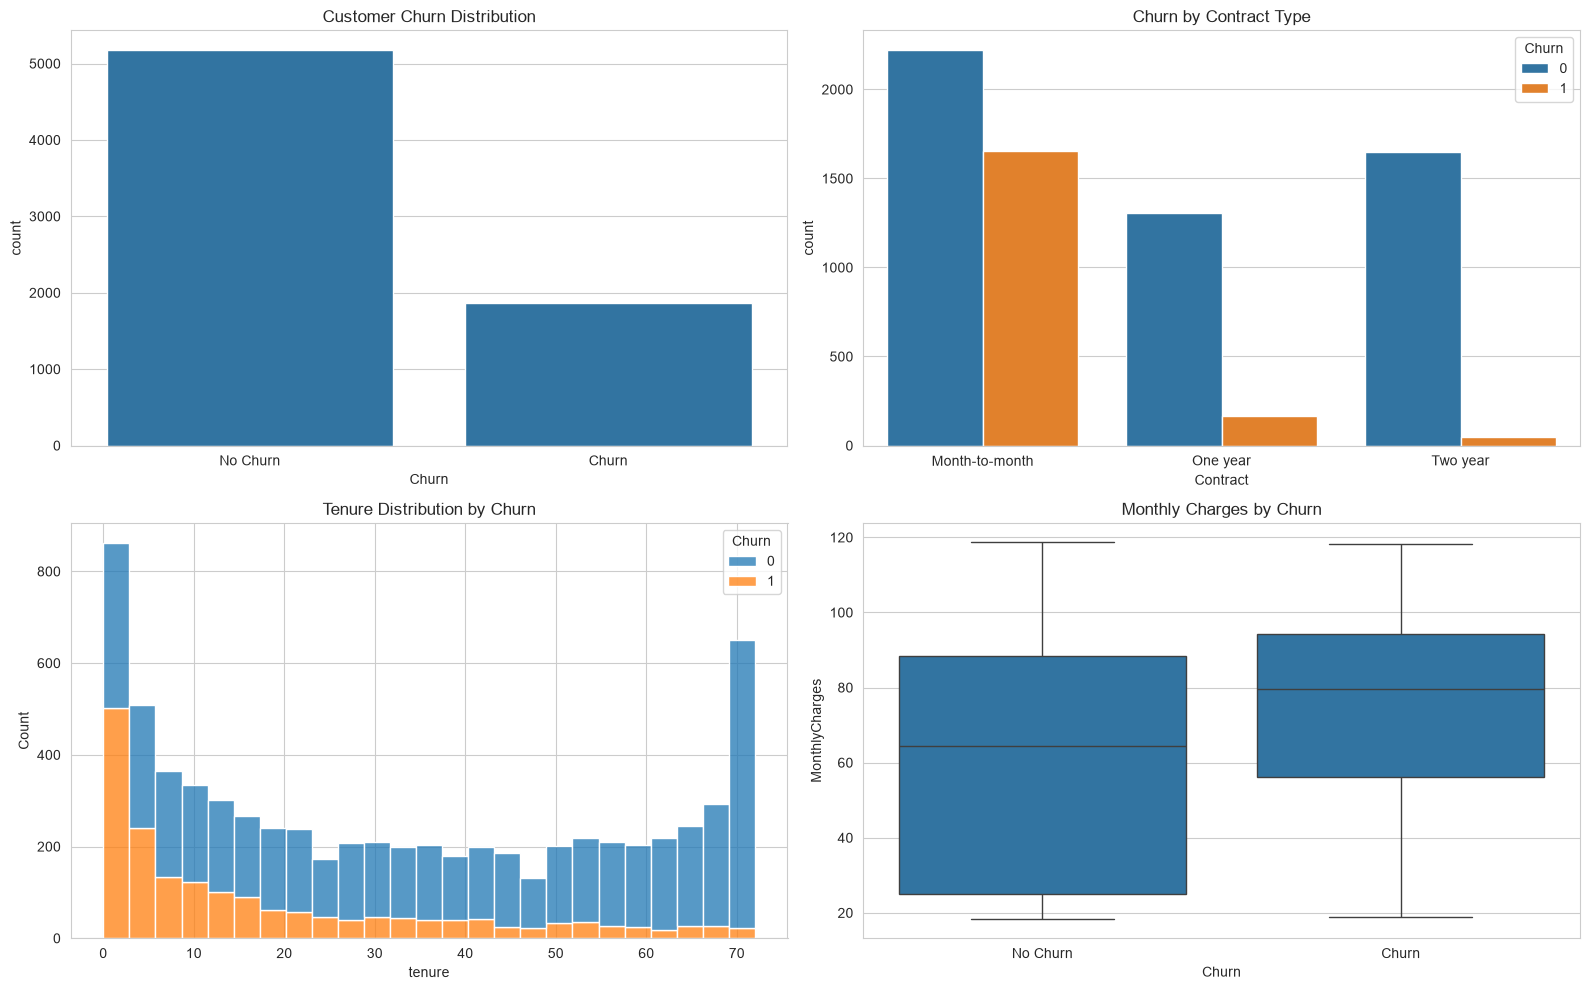

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Overall churn count
sns.countplot(data=df, x="Churn", ax=axes[0, 0])
axes[0, 0].set_title("Customer Churn Distribution")
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(["No Churn", "Churn"])

# 2. Contract type vs churn
sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[0, 1])
axes[0, 1].set_title("Churn by Contract Type")

# 3. Tenure distribution vs churn
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=25, ax=axes[1, 0])
axes[1, 0].set_title("Tenure Distribution by Churn")

# 4. Monthly charges vs churn
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1, 1])
axes[1, 1].set_title("Monthly Charges by Churn")
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(["No Churn", "Churn"])

plt.tight_layout()
plt.show()

In [15]:
print("Churn rate by contract type (%):")
print((df.groupby("Contract")["Churn"].mean() * 100).round(2))

print("\nChurn rate by internet service (%):")
print((df.groupby("InternetService")["Churn"].mean() * 100).round(2))

print("\nChurn rate by payment method (%):")
print((df.groupby("PaymentMethod")["Churn"].mean() * 100).round(2))

Churn rate by contract type (%):
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

Churn rate by internet service (%):
InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64

Churn rate by payment method (%):
PaymentMethod
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11
Name: Churn, dtype: float64


In [16]:
from sklearn.model_selection import train_test_split

# customerID ही unique identification आहे; modelसाठी उपयोगी नाही
X = df.drop(columns=["customerID", "Churn"])

# Churn हा target आहे
y = df["Churn"]

# 80% training आणि 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining churn rate:", round(y_train.mean() * 100, 2), "%")
print("Testing churn rate:", round(y_test.mean() * 100, 2), "%")

X_train shape: (5634, 19)
X_test shape: (1409, 19)

Training churn rate: 26.54 %
Testing churn rate: 26.54 %


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Numeric आणि categorical columns वेगळे करा
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "str"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Numeric columns scale करा; text categories one-hot encode करा
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Full model pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]
)

# Train model
logistic_model.fit(X_train, y_train)

# Predictions
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

# Metrics
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr), 4))
print("Recall:", round(recall_score(y_test, y_pred_lr), 4))
print("F1-score:", round(f1_score(y_test, y_pred_lr), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_lr), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Accuracy: 0.8055
Precision: 0.6572
Recall: 0.5588
F1-score: 0.604
ROC-AUC: 0.8421

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



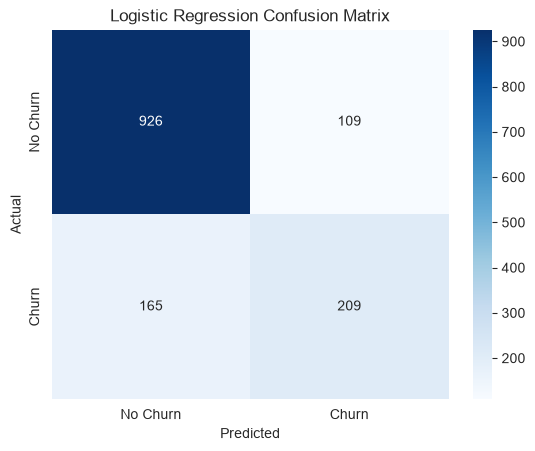

In [18]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [19]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

# Train model
random_forest_model.fit(X_train, y_train)

# Predictions
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Metrics
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
print("F1-score:", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7708
Precision: 0.5606
Recall: 0.631
F1-score: 0.5937
ROC-AUC: 0.822

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.56      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409



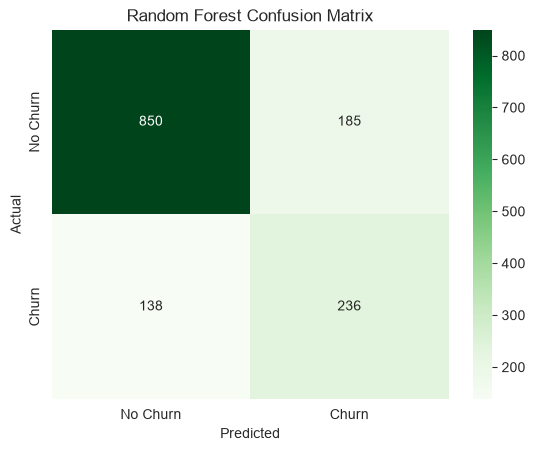

In [20]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [21]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421
1,Random Forest,0.7708,0.5606,0.6310,0.5937,0.8220


In [22]:
from pathlib import Path
import joblib

# models folder तयार करा
Path("models").mkdir(exist_ok=True)

# Best model save करा
joblib.dump(logistic_model, "models/churn_model.joblib")

print("Model saved successfully.")

Model saved successfully.


In [23]:
print(list(Path("models").glob("*")))

[WindowsPath('models/churn_model.joblib')]
